In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import time
import os
import psutil

# --- START BENCHMARKING ---
overall_start = time.time()
process = psutil.Process(os.getpid())

# --- 1. LOAD DATA ---
print("Loading fixed genotypes (310 samples, 50k SNPs)...")
genotypes = pd.read_csv('manual_gwas_input_final.raw', sep=r'\s+', low_memory=False)

y = genotypes.iloc[:, 5].values
snp_names_raw = genotypes.columns[6:]
X = genotypes.iloc[:, 6:].values

# Impute and Center
X[np.isnan(X)] = np.take(np.nanmean(X, axis=0), np.where(np.isnan(X))[1])
n, m = X.shape

# --- 1.5 MANUAL LD PRUNING (New Section) ---
print("Starting LD Pruning for PCA...")
pruning_start = time.time()

window_size = 50
step_size = 5
r2_threshold = 0.2
kept_indices = []

# We iterate through the SNPs in windows
for i in range(0, m - window_size, step_size):
    window = X[:, i:i + window_size]
    corr_matrix = np.corrcoef(window, rowvar=False)

    # Simple logic: if a SNP is highly correlated with any previous SNP in the window, skip it
    for j in range(window_size):
        idx = i + j
        is_redundant = False
        for k in range(j):
            if corr_matrix[j, k]**2 > r2_threshold:
                is_redundant = True
                break
        if not is_redundant and idx not in kept_indices:
            kept_indices.append(idx)

X_pruned = X[:, kept_indices]
print(f"Pruning complete. Reduced SNPs from {m} to {len(kept_indices)} for PCA.")
pruning_end = time.time()

# --- 2. MANUALLY COMPUTE PCs (Updated Section) ---
pca_start = time.time()
print("Computing Principal Components via SVD on PRUNED data...")

# Use X_pruned instead of X_std for the SVD
X_std_pruned = (X_pruned - np.mean(X_pruned, axis=0)) / np.std(X_pruned, axis=0)
X_std_pruned = np.nan_to_num(X_std_pruned)

U, S, Vt = np.linalg.svd(X_std_pruned, full_matrices=False)
PCs = U[:, :3]
pca_end = time.time()
print(f"Matrix dimensions: {n} samples x {m} SNPs")



# --- 3. VECTORIZED PCA-CORRECTED GWAS MATH (Timed Section) ---
math_start = time.time()
print(f"Running vectorized corrected GWAS for {m} SNPs...")

# A. Construct Projection Matrix M_Z (Intercept + 3 PCs)
Z = np.hstack([np.ones((n, 1)), PCs])
# M_Z = I - Z(Z'Z)^-1 Z'
M_Z = np.eye(n) - Z @ np.linalg.inv(Z.T @ Z) @ Z.T

# B. Residualize Phenotype and Genotypes
# This removes the ancestry signal (PCs) from the data
y_star = M_Z @ y
X_star = M_Z @ X

# C. Vectorized Regression on Residuals
numerator = np.dot(X_star.T, y_star)
denominator = np.sum(X_star**2, axis=0)
denominator[denominator == 0] = np.nan
betas = numerator / denominator

# D. Standard Error Calculation
# df = n - (intercept + 3 PCs + 1 SNP) = n - 5
df = n - Z.shape[1] - 1
y_pred = X_star * betas
rss = np.sum((y_star[:, np.newaxis] - y_pred)**2, axis=0)
se = np.sqrt(rss / df) / np.sqrt(denominator)

p_vals = stats.t.sf(np.abs(betas/se), df) * 2
math_end = time.time()

# --- 4. SAVE RESULTS ---
results = pd.DataFrame({
    'SNP': [name.split('_')[0] for name in snp_names_raw],
    'BETA': betas,
    'P': p_vals
}).dropna()

results.to_csv('manual_gwas_pca_corrected.csv', index=False)

# --- FINAL BENCHMARK PRINTING ---
overall_end = time.time()
mem_usage = process.memory_info().rss / (1024 * 1024) # Convert to MB

print("\n" + "="*35)
print("PCA-CORRECTED GWAS BENCHMARK REPORT")
print("="*35)
print(f"SVD Execution Time:           {pca_end - pca_start:.4f} seconds")
print(f"GWAS Math Execution Time:     {math_end - math_start:.4f} seconds")
print(f"Total Execution Time:         {overall_end - overall_start:.4f} seconds")
print(f"Peak Memory Usage:            {mem_usage:.2f} MB")
print(f"Matrix X theoretical size:    {X.nbytes / (1024*1024):.2f} MB")
print("="*35)

# Quick Validation: Top Hits
print("\nTop 5 Hits after Correction:")
print(results.sort_values('P').head(5))

Loading fixed genotypes (310 samples, 50k SNPs)...
Starting LD Pruning for PCA...
Pruning complete. Reduced SNPs from 50000 to 25742 for PCA.
Computing Principal Components via SVD on PRUNED data...
Matrix dimensions: 310 samples x 50000 SNPs
Running vectorized corrected GWAS for 50000 SNPs...

PCA-CORRECTED GWAS BENCHMARK REPORT
SVD Execution Time:           5.4152 seconds
GWAS Math Execution Time:     0.9351 seconds
Total Execution Time:         42.3166 seconds
Peak Memory Usage:            1358.96 MB
Matrix X theoretical size:    118.26 MB

Top 5 Hits after Correction:
             SNP      BETA             P
7472   rs5999704  9.257304  1.991981e-20
7504  rs73386262  9.065485  3.966566e-20
7496   rs6518997  9.131440  4.011588e-20
7434  rs60882067  8.873193  1.147335e-19
7508   rs5999880  8.796546  1.611376e-19


In [ ]:
import pandas as pd
import numpy as np

# Load your results and the causal list
results = pd.read_csv('manual_gwas_pca_corrected.csv')
causal_list = pd.read_csv('causal.snplist', header=None)[0].values

# Filter for causal SNPs
causal_hits = results[results['SNP'].isin(causal_list)].copy()

# Calculate -log10(P) for easier reading
causal_hits['-log10P'] = -np.log10(causal_hits['P'])

print(f"Found {len(causal_hits)} out of 20 causal SNPs in the results.")
print("\nTop Causal SNPs recovered:")
print(causal_hits.sort_values(by='P'))

Found 20 out of 20 causal SNPs in the results.

Top Causal SNPs recovered:
               SNP      BETA             P    -log10P
7496     rs6518997  9.131440  4.011588e-20  19.396684
43119     rs130859  5.943077  2.453585e-09   8.610199
13251  rs116540727  3.490263  1.050252e-07   6.978706
7730     rs6000605  3.701961  1.079016e-06   5.966972
15446    rs2283825  2.621079  2.549426e-04   3.593558
12701    rs5751937 -1.897435  5.137997e-04   3.289206
9715    rs12159358 -2.733019  6.911567e-04   3.160423
45305    rs5771636  2.069573  1.709596e-03   2.767107
37407     rs139075  1.757289  2.770187e-03   2.557491
21234   rs73884225  2.803259  4.284717e-03   2.368078
40058   rs13054344 -2.253855  9.297502e-03   2.031634
15077     rs137193  1.330822  3.158796e-02   1.500478
26025     rs361845 -1.351167  4.115397e-02   1.385588
41905     rs801705  1.603393  1.942625e-01   0.711611
14856     rs134696  0.827362  1.976439e-01   0.704117
9390      rs435053 -0.758201  2.419166e-01   0.616334
30208  

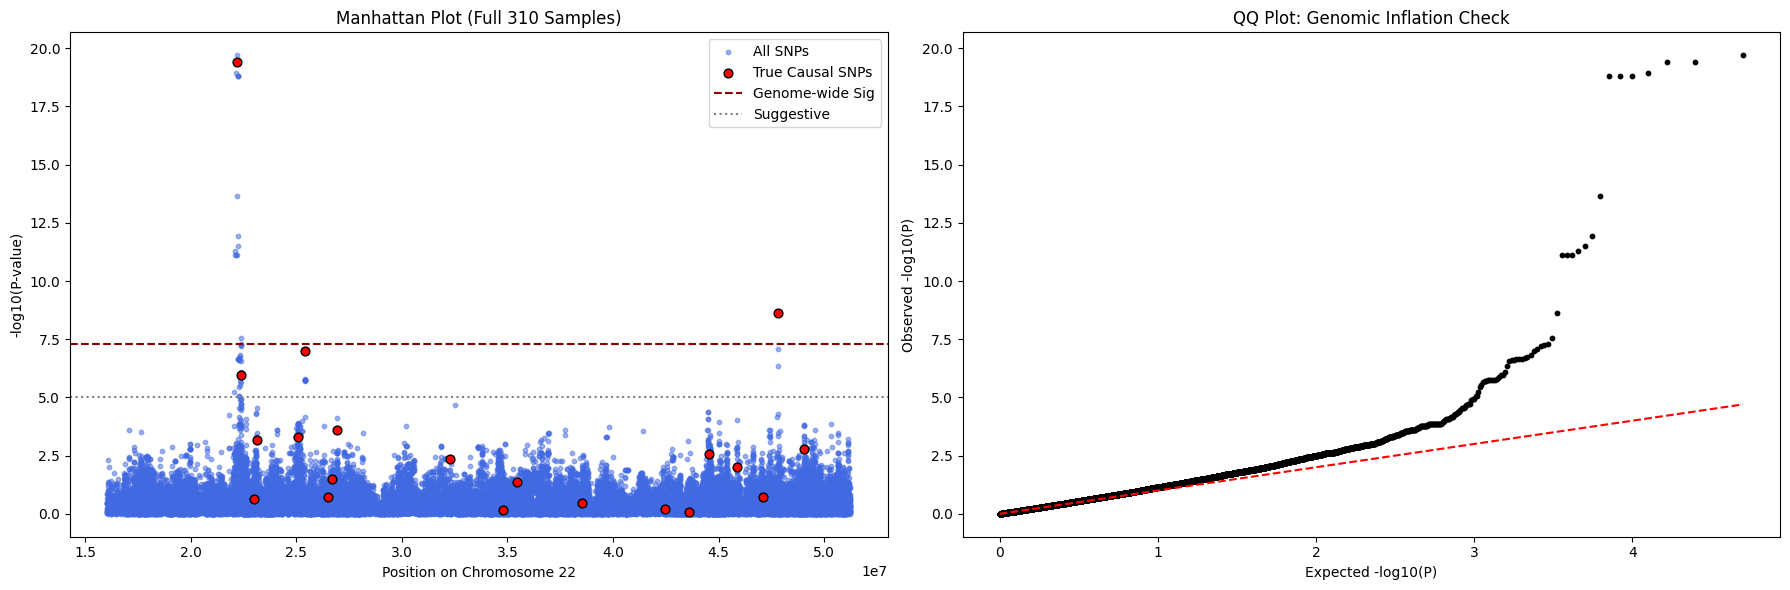

Genomic Inflation Factor (Lambda GC): 1.127


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for Manhattan Plot
# We need the .bim file to get chromosomal positions
bim = pd.read_csv('chr22_with_pheno.bim', sep=r'\s+', header=None,
                 names=['CHR', 'SNP', 'CM', 'POS', 'A1', 'A2'])

df = pd.merge(results, bim[['SNP', 'POS']], on='SNP')
df['-log10P'] = -np.log10(df['P'])
df = df.sort_values('POS')

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Manhattan Plot ---
ax1.scatter(df['POS'], df['-log10P'], c='royalblue', s=10, alpha=0.5, label='All SNPs')

# Highlight causal SNPs in Red
causal_df = df[df['SNP'].isin(causal_list)]
ax1.scatter(causal_df['POS'], causal_df['-log10P'], c='red', s=40, label='True Causal SNPs', edgecolors='black')

# Add significance lines
ax1.axhline(y=-np.log10(5e-8), color='darkred', linestyle='--', label='Genome-wide Sig')
ax1.axhline(y=-np.log10(1e-5), color='gray', linestyle=':', label='Suggestive')

ax1.set_title('Manhattan Plot (Full 310 Samples)')
ax1.set_xlabel('Position on Chromosome 22')
ax1.set_ylabel('-log10(P-value)')
ax1.legend()

# --- QQ Plot ---
observed = np.sort(df['P'])
expected = np.arange(1, len(observed) + 1) / (len(observed) + 1)

ax2.scatter(-np.log10(expected), -np.log10(observed), c='black', s=10)
max_val = np.max(-np.log10(expected))
ax2.plot([0, max_val], [0, max_val], color='red', linestyle='--')

ax2.set_title('QQ Plot: Genomic Inflation Check')
ax2.set_xlabel('Expected -log10(P)')
ax2.set_ylabel('Observed -log10(P)')

plt.tight_layout()
plt.show()

# 3. Calculate Genomic Inflation (Lambda)
from scipy import stats
chisq = stats.chi2.ppf(1 - df['P'], 1)
lambda_gc = np.median(chisq) / 0.454
print(f"Genomic Inflation Factor (Lambda GC): {lambda_gc:.3f}")

In [ ]:
# Calculate Lambda GC
# We convert P-values to Chi-squared statistics
chisq = stats.chi2.ppf(1 - results['P'], 1)
lambda_gc = np.median(chisq) / 0.454

print(f"Genomic Inflation Factor (Lambda GC): {lambda_gc:.3f}")

if lambda_gc > 1.1:
    print("WARNING: Severe population inflation detected. Your 'hits' may be false positives.")
else:
    print("The study is well-calibrated.")

Genomic Inflation Factor (Lambda GC): 1.127


In [ ]:
# Count how many non-causal SNPs passed the significance threshold (5e-8)
false_positives = results[(~results['SNP'].isin(causal_list)) & (results['P'] < 5e-8)]
print(f"Number of False Positives: {len(false_positives)}")

Number of False Positives: 14


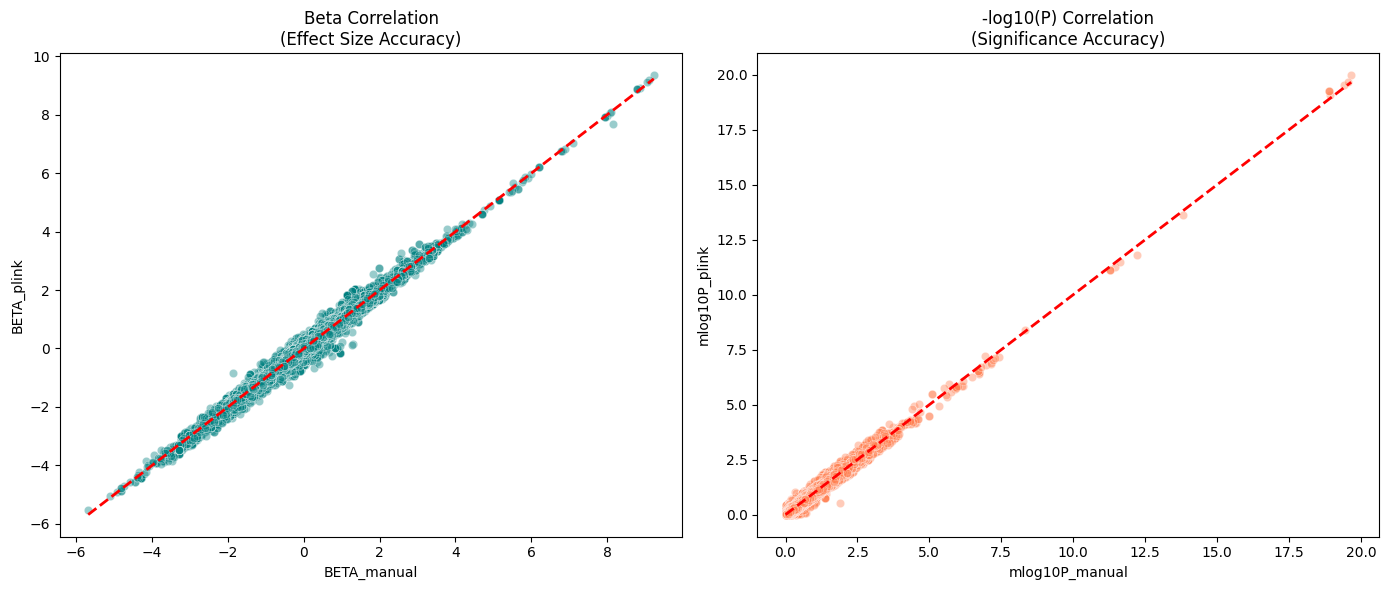

Metric               | Manual     | PLINK     
---------------------------------------------
Lambda_GC            | 1.1198     | 1.1211    
P-value Correlation  | 0.965820  
Beta Correlation     | 0.992393  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the PCA-Corrected results
manual = pd.read_csv('manual_gwas_pca_corrected.csv')
plink = pd.read_csv('plink_final_benchmark.assoc.linear', sep=r'\s+')
plink = plink[plink['TEST'] == 'ADD']

# Merge datasets on SNP ID
merged = pd.merge(manual, plink, on='SNP', suffixes=('_manual', '_plink'))

# 2. Calculate Lambda_GC for both
def get_lambda(p_vals):
    chi2 = stats.chi2.ppf(1 - p_vals, 1)
    return np.median(chi2) / 0.455

lambda_manual = get_lambda(merged['P_manual'])
lambda_plink = get_lambda(merged['P_plink'])

# 3. Visualization (Beta and -log10P)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Beta Comparison
sns.scatterplot(data=merged, x='BETA_manual', y='BETA_plink', ax=ax1, alpha=0.4, color='teal')
ax1.plot([merged['BETA_manual'].min(), merged['BETA_manual'].max()],
         [merged['BETA_manual'].min(), merged['BETA_manual'].max()], 'r--', lw=2)
ax1.set_title(f'Beta Correlation\n(Effect Size Accuracy)')

# P-value Comparison
merged['mlog10P_manual'] = -np.log10(merged['P_manual'])
merged['mlog10P_plink'] = -np.log10(merged['P_plink'])
sns.scatterplot(data=merged, x='mlog10P_manual', y='mlog10P_plink', ax=ax2, alpha=0.4, color='coral')
ax2.plot([0, merged['mlog10P_manual'].max()], [0, merged['mlog10P_manual'].max()], 'r--', lw=2)
ax2.set_title(f'-log10(P) Correlation\n(Significance Accuracy)')

plt.tight_layout()
plt.show()

# 4. Final Benchmarking Printout
print(f"{'Metric':<20} | {'Manual':<10} | {'PLINK':<10}")
print("-" * 45)
print(f"{'Lambda_GC':<20} | {lambda_manual:<10.4f} | {lambda_plink:<10.4f}")
print(f"{'P-value Correlation':<20} | {merged['P_manual'].corr(merged['P_plink']):<10.6f}")
print(f"{'Beta Correlation':<20} | {merged['BETA_manual'].corr(merged['BETA_plink']):<10.6f}")